In [2]:

using PKAssetPrices.Dynamic: DynamicModel, DiscreteTime, DynamicParametrization, solve_model, @model
using PKAssetPrices
using CairoMakie


SYSTEM: caught exception of type :MethodError while trying to print a failed Task notice; giving up
[ Info: AD = 4.21
[ Info: AQ = 6.0
[ Info: P = 1.76
[ Info: AP = 2.0
[ Info: r = 0.11
[ Info: AD = 4.21
[ Info: AQ = 6.0
[ Info: P = 1.76
[ Info: AP = 2.0
[ Info: r = 0.11
[ Info: AQ = 6.0
[ Info: P = 1.76
[ Info: AP = 2.0
[ Info: r = 0.11
[ Info: AQ = 6.0
[ Info: P = 1.76
[ Info: AP = 2.0
[ Info: r = 0.11
[ Info: AQ = 6.0
[ Info: P = 1.76
[ Info: AP = 2.0
[ Info: r = 0.11
[ Info: P = 1.76
[ Info: AP = 2.0
[ Info: r = 0.11
[ Info: AQ = 6.0
[ Info: P = 1.06
[ Info: AP = [1.0, 1.0]
[ Info: r = 0.11
[ Info: AQ = 6.0
[ Info: P = 1.76
[ Info: AP = 1.0
[ Info: r = 0.11
[ Info: AQ = 6.0
[ Info: P = 1.0
[ Info: AP = [1.0, 1.0]
[ Info: r = 0.11
[ Info: AQ = 6.0
[ Info: P = 1.76
[ Info: AP = [1.0, 1.0]
[ Info: r = 0.11
[ Info: AQ = 6.0
[ Info: P = 1.76
[ Info: AP = [1.0, 1.0]
[ Info: r = 0.11
[ Info: AQ = 6.0
[ Info: P = 1.76
[ Info: AP = [1.0, 1.0]
[ Info: r = 0.11
[ Info: AQ = 6.0
[ Info: P = 1

In [3]:
sol_baseline =  solve_model(Dynamic.DynQconAPLevelChange2)

PKAssetPrices.Dynamic.DynamicSolution{PKAssetPrices.Dynamic.var"#83#84", PKAssetPrices.Dynamic.var"#85#86", Float64, Vector{Float64}}(DynamicParametrization{PKAssetPrices.Dynamic.var"#83#84", PKAssetPrices.Dynamic.var"#85#86", Float64, Vector{Float64}}(DynamicModel{PKAssetPrices.Dynamic.var"#83#84", PKAssetPrices.Dynamic.var"#85#86"}(DiscreteTime([0.0, 1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0  …  91.0, 92.0, 93.0, 94.0, 95.0, 96.0, 97.0, 98.0, 99.0, 100.0]), PKAssetPrices.Dynamic.DynVar[PKAssetPrices.Dynamic.DynVar(:Y, "Output"), PKAssetPrices.Dynamic.DynVar(:ND, "Non debt-financed demand"), PKAssetPrices.Dynamic.DynVar(:D, "debt-financed demand"), PKAssetPrices.Dynamic.DynVar(:i, "policy rate"), PKAssetPrices.Dynamic.DynVar(:r, "interest rate"), PKAssetPrices.Dynamic.DynVar(:P, "price level"), PKAssetPrices.Dynamic.DynVar(:dL, "change in loans"), PKAssetPrices.Dynamic.DynVar(:dM, "change in money"), PKAssetPrices.Dynamic.DynVar(:dR, "change in reserves"), PKAssetPrices.Dynamic.DynV

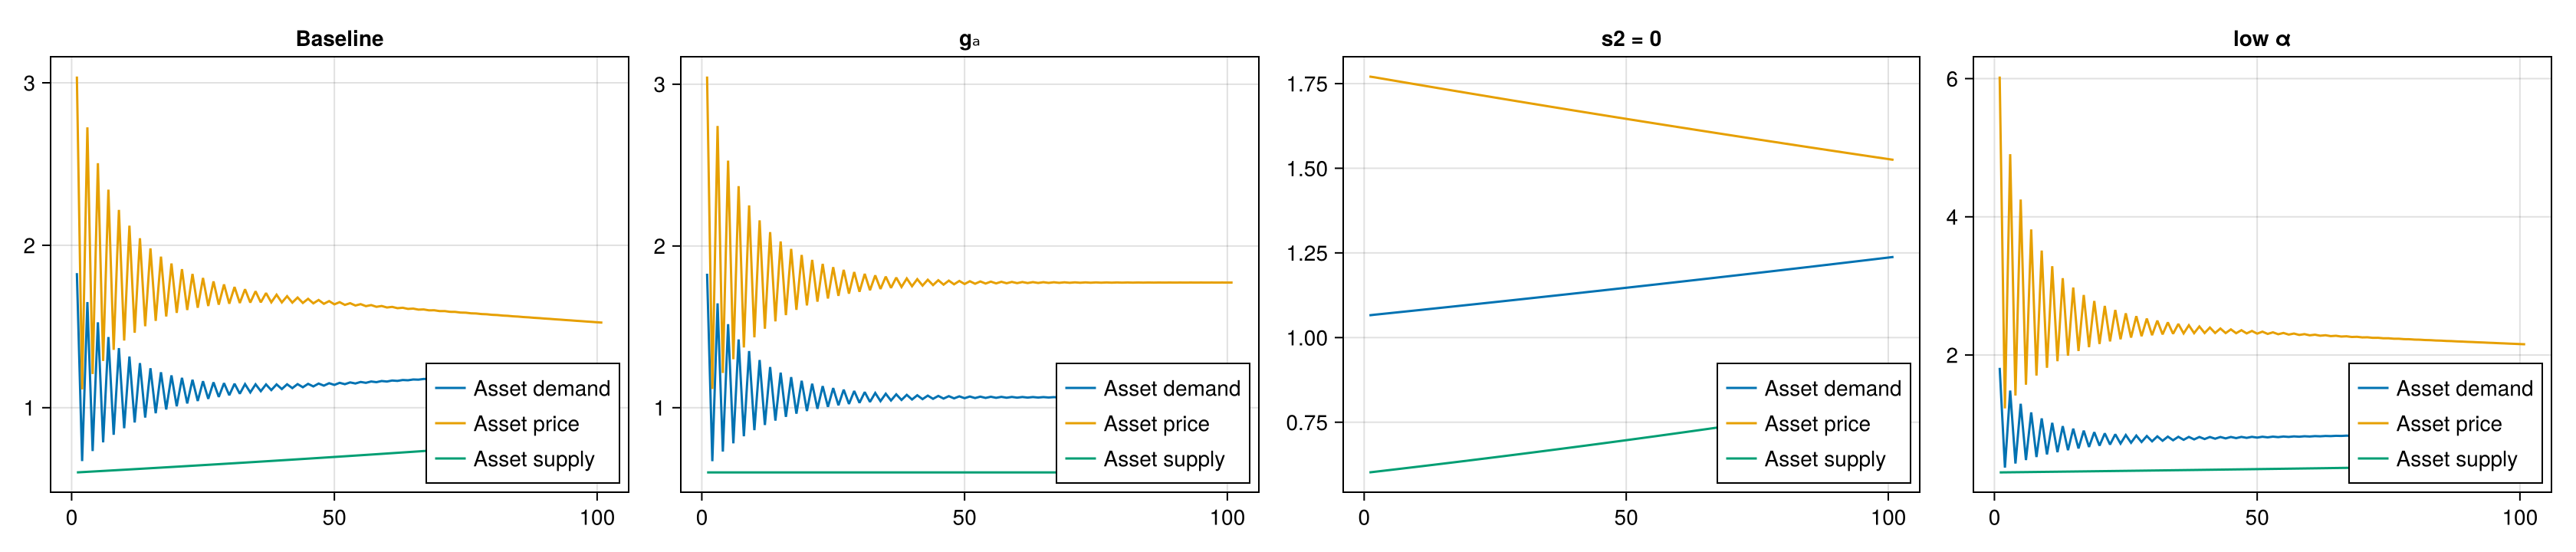

In [4]:
baseline = Plotting.run_dynq_case()

cases = [
    (;label = "Baseline", sol = baseline),
    (;label = "gₐ", sol = Plotting.run_dynq_case(overwrites =  (:gₐ => 0.0,))),
    (;label = "s2 = 0", sol = Plotting.run_dynq_case(overwrites =  (:s2 => 0.0,))),
    (;label = "low α", sol = Plotting.run_dynq_case(overwrites =  (:α => 0.05,))),
]
Plotting.compare_dynq_cases(cases; vars = [:AD, :AP, :AS])
# compare_dynq_cases(cases; vars = [:Y, :W, :N, :U], ylabel = "Real side", sharey = true)


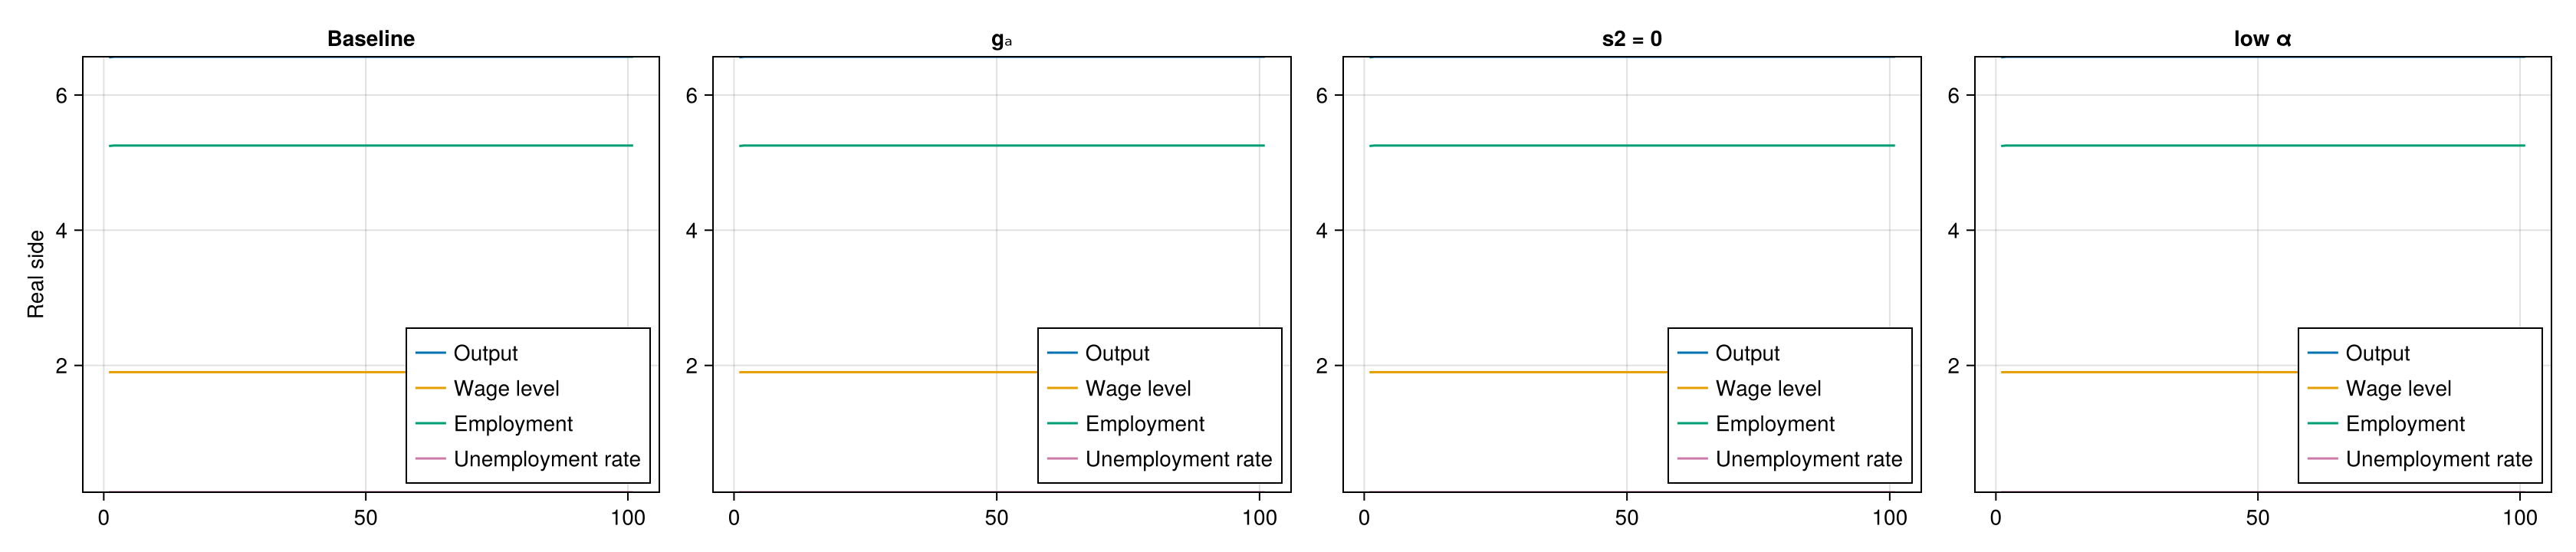

In [6]:
Plotting.compare_dynq_cases(cases; vars = [:Y, :W, :N, :U], ylabel = "Real side", sharey = true)

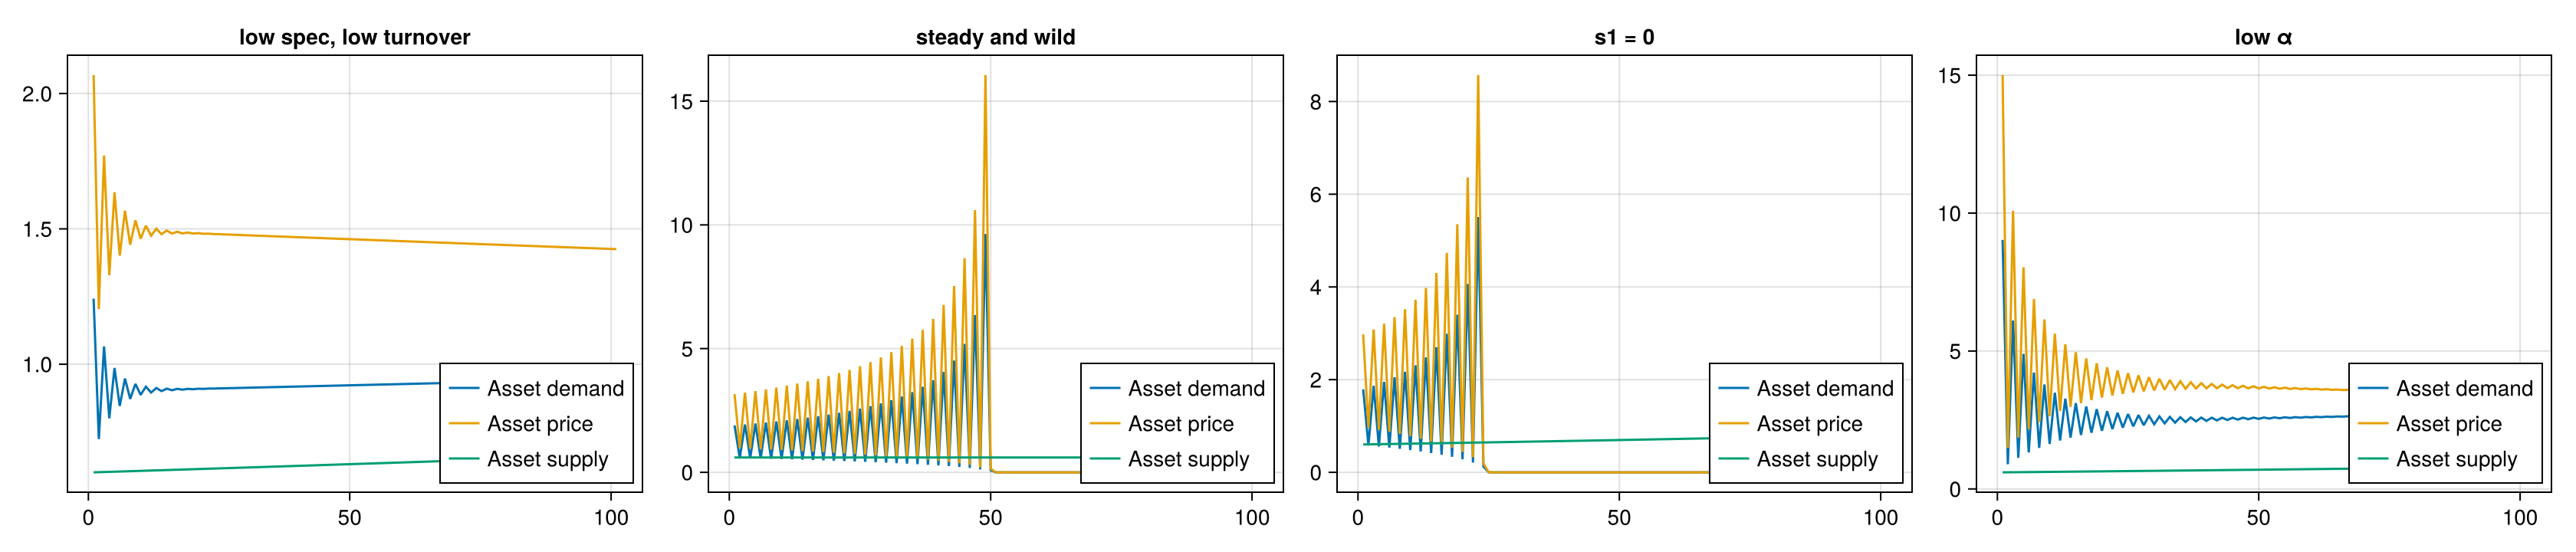

In [11]:

cases = [
    (; label = "low spec, low turnover", sol = Plotting.run_dynq_case(overwrites = ( :s2 => 0.8, :γ => 0.3, :gₐ => 0.001))),
    (; label = "steady and wild", sol = Plotting.run_dynq_case(overwrites = ( :gₐ => 0.0, :s2 => 0.95))),
    (; label = "s1 = 0", sol = Plotting.run_dynq_case(overwrites = ( :s1 => 1,))),
    (; label = "low α", sol = Plotting.run_dynq_case(overwrites = ( :γ => 0.9,))),
]

Plotting.compare_dynq_cases(cases; vars = [:AD, :AP, :AS])

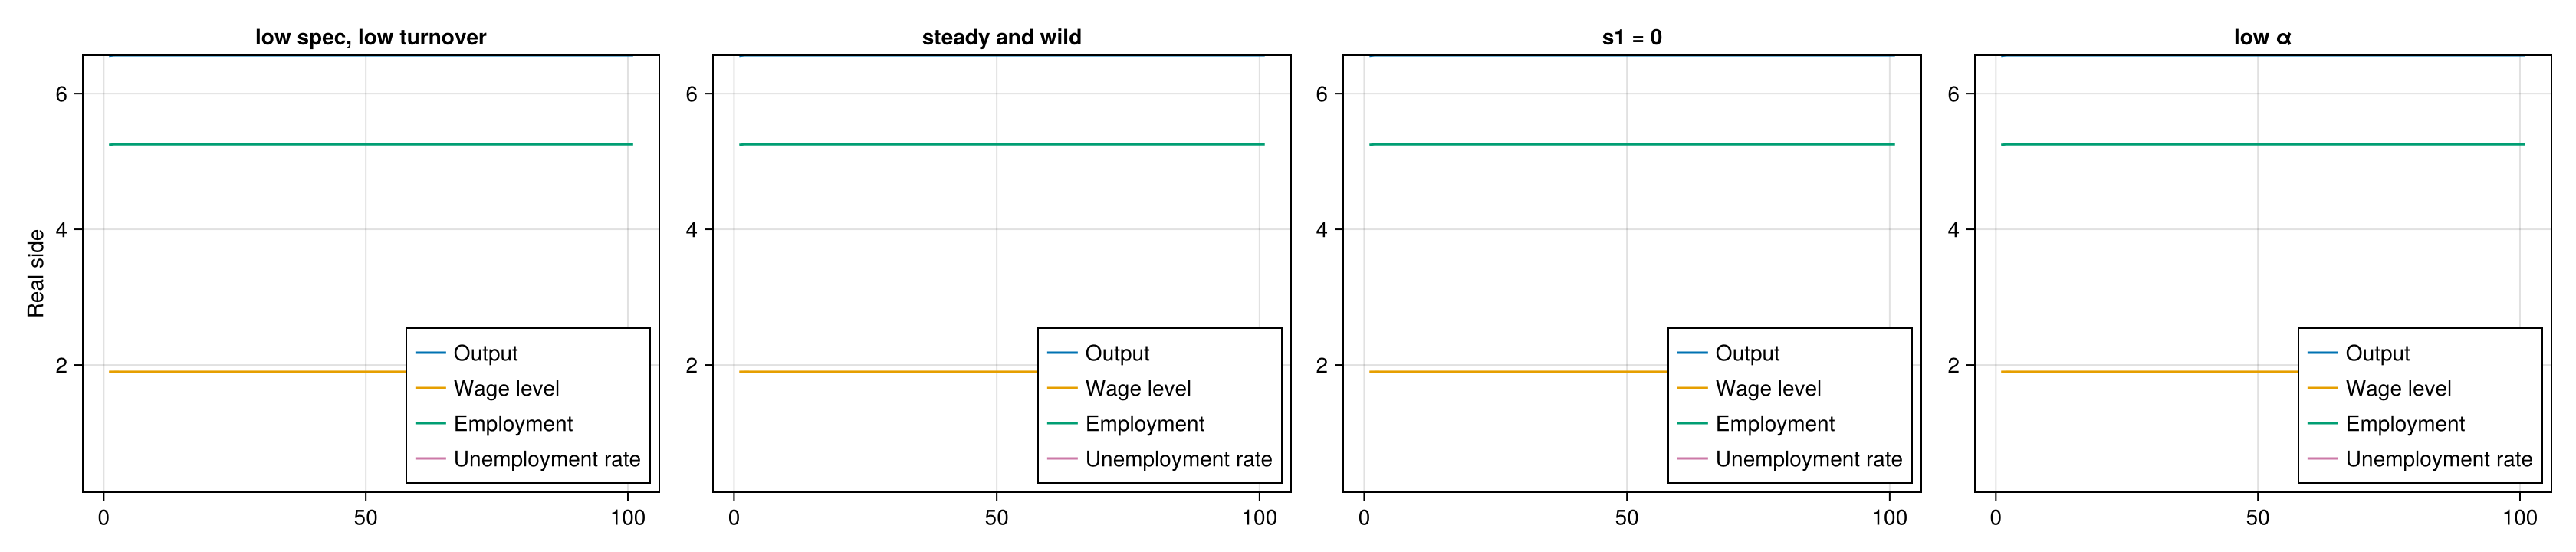

In [ ]:
Plotting.compare_dynq_cases(cases; vars = [:Y, :W, :N, :U], ylabel = "Real side", sharey = true)u

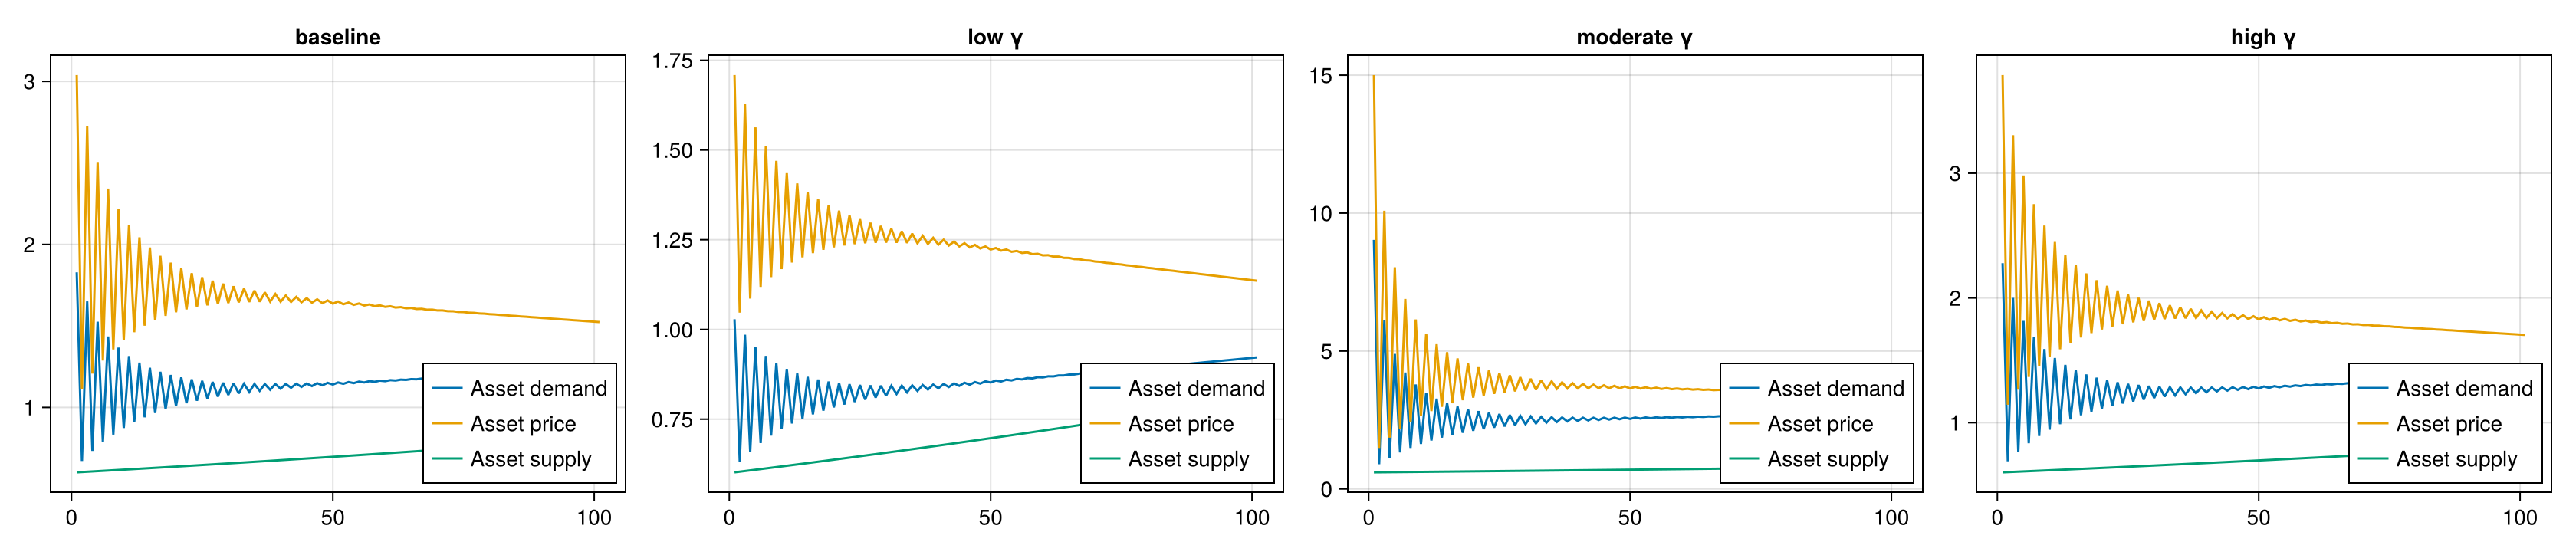

In [14]:
cases = [
    (; label = "baseline", sol = Plotting.run_dynq_case()),
    (; label = "low γ", sol = Plotting.run_dynq_case(overwrites = ( :γ => 0.1,))),
    (; label = "moderate γ", sol = Plotting.run_dynq_case(overwrites = ( :s2 => 0.9, :γ => 0.9,))),
    (; label = "high γ", sol = Plotting.run_dynq_case(overwrites = ( :γ => 0.6,))),
]

Plotting.compare_dynq_cases(cases; vars = [:AD, :AP, :AS])


# Asset market

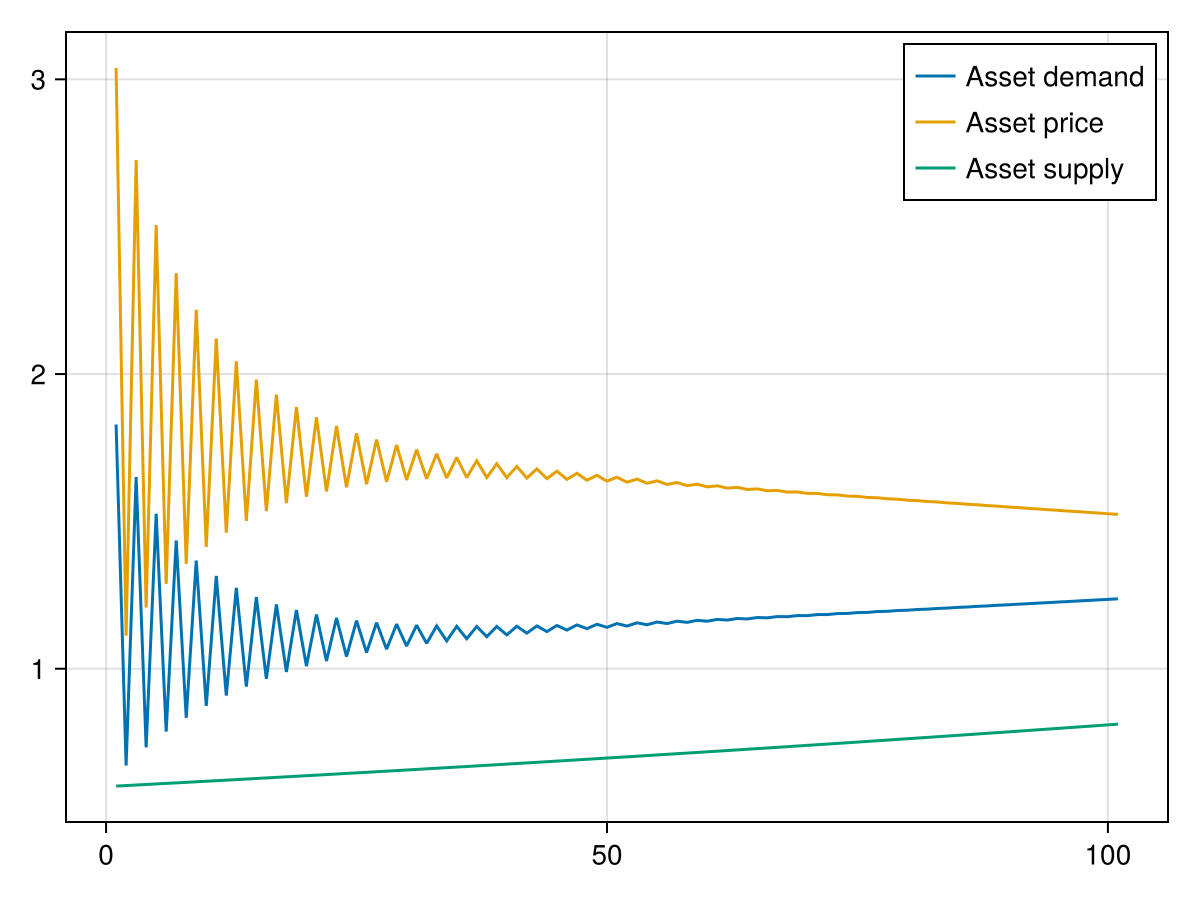

In [12]:

f = Figure()
ax = Axis(f[1,1])
lines!(ax,sol_baseline.paths[:AD], label = "Asset demand")
lines!(ax,sol_baseline.paths[:AP], label = "Asset price")
lines!(ax,sol_baseline.paths[:AS], label = "Asset supply")
axislegend(ax)
f

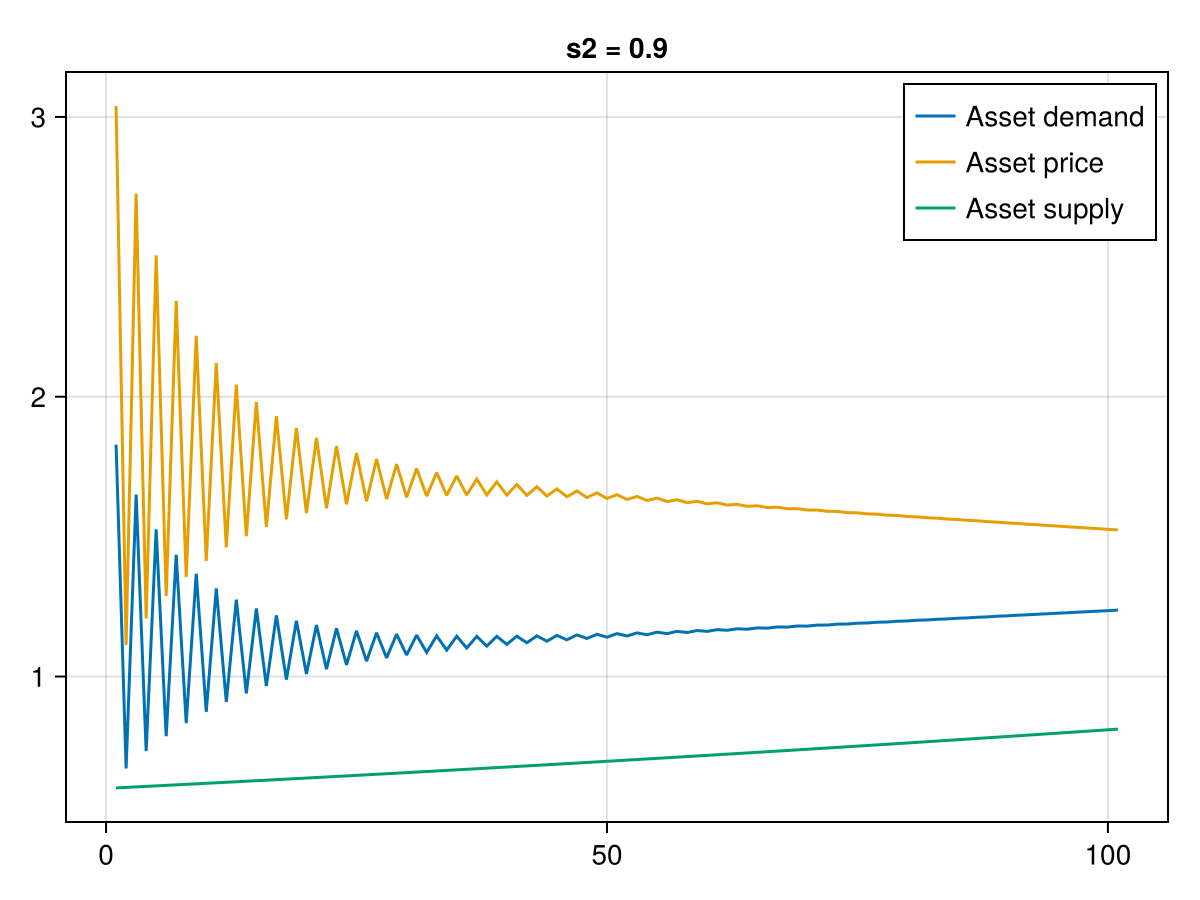

In [4]:
Plotting.create_gif(model = Dynamic.DynQconAPLevelChange2,
        param_name = :s2,
        param_range = range(0.1, 0.9, length = 100),
        filename = "../plots/asset_market_s2_animation.gif")

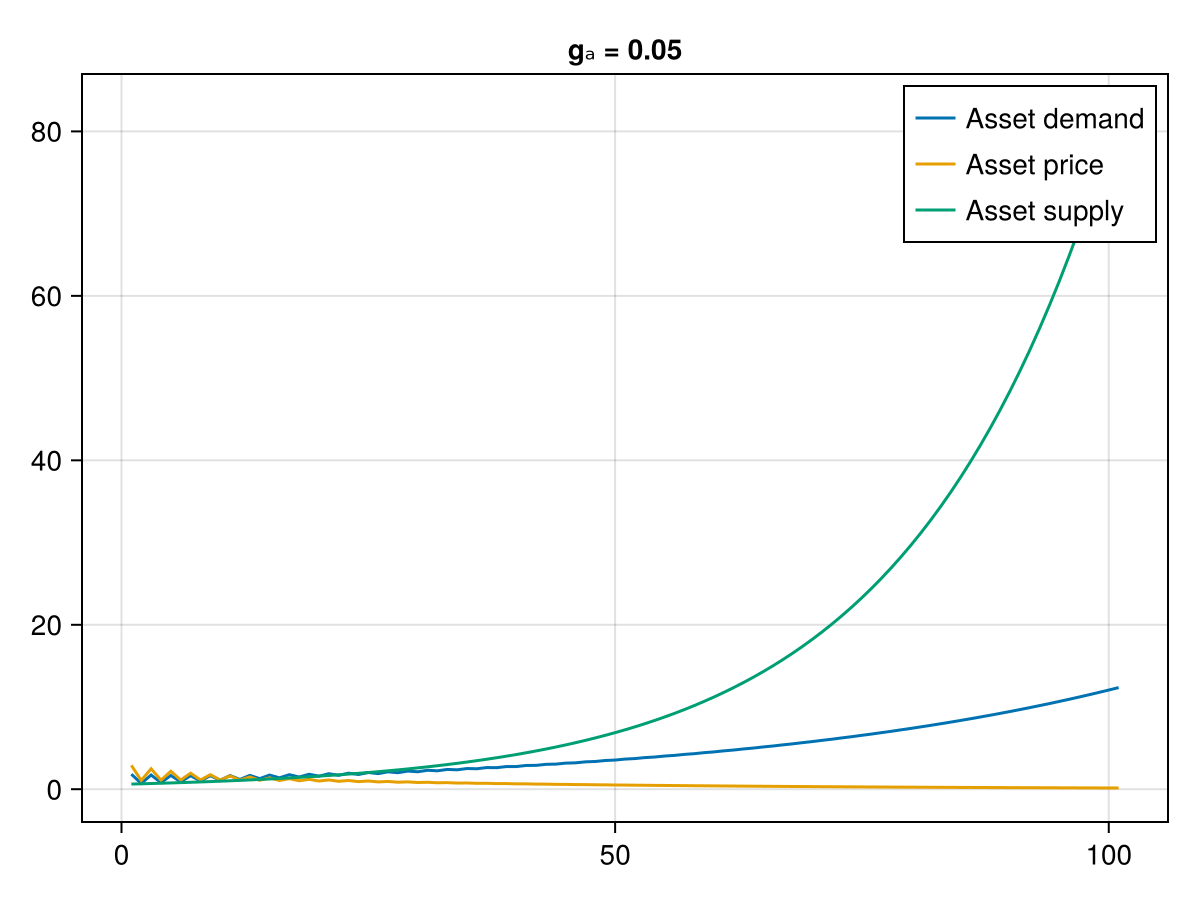

In [5]:
Plotting.create_gif(model = Dynamic.DynQconAPLevelChange2,
        param_name = :gₐ,
        param_range = range(0.0001, 0.05, length = 100),
        filename = "../plots/asset_market_ga_animation.gif")

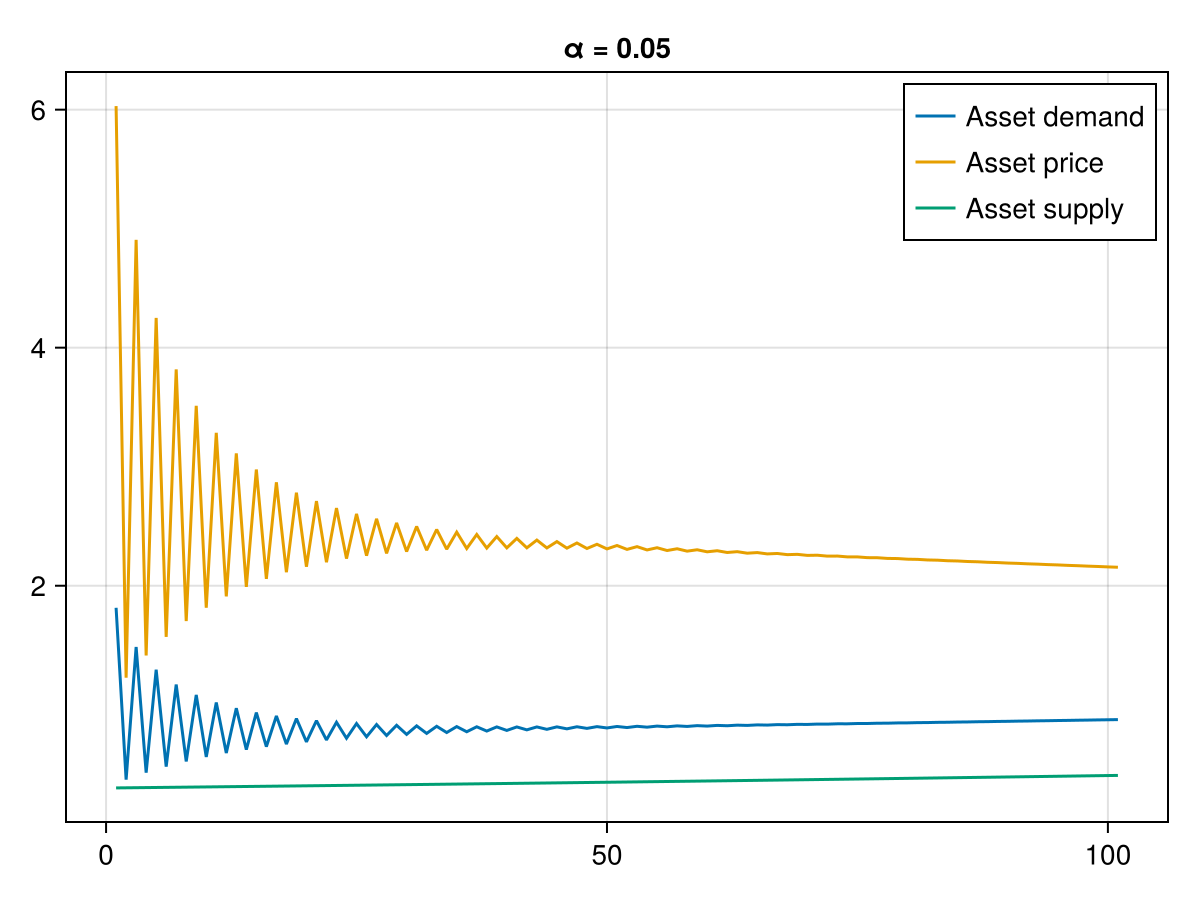

In [6]:
Plotting.create_gif(model = Dynamic.DynQconAPLevelChange2,
        param_name = :α,
        param_range = range(0.0001, 0.05, length = 100),
        filename = "../plots/asset_market_α_animation.gif")

# Real economy


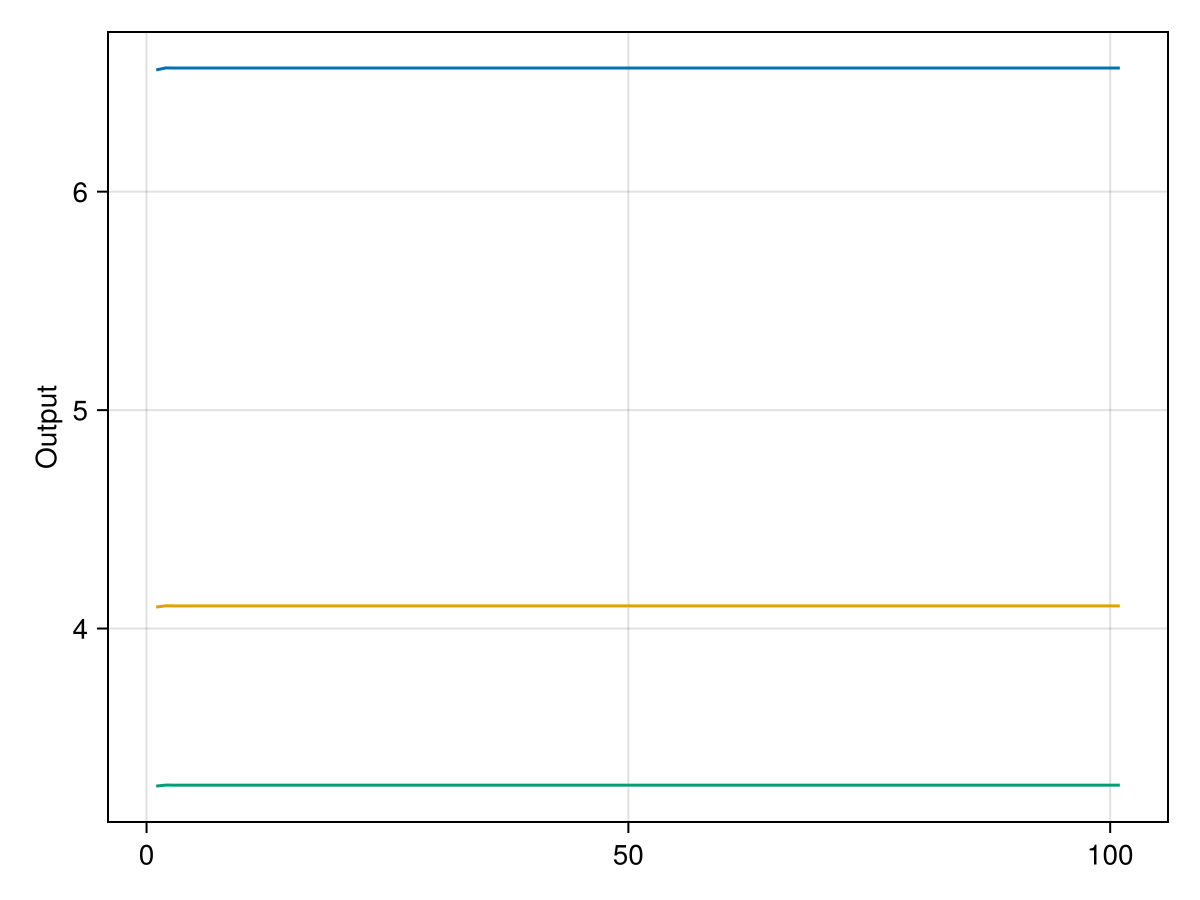

In [15]:
f = Figure()
ax = Axis(f[1,1], ylabel = "Output")

lines!(ax,sol_baseline.paths[:Y], label = "GDP")
lines!(ax,sol_baseline.paths[:D], label = "Debt financed demand")
lines!(ax,sol_baseline.paths[:ND], label = "Non-debt financed deman")
f

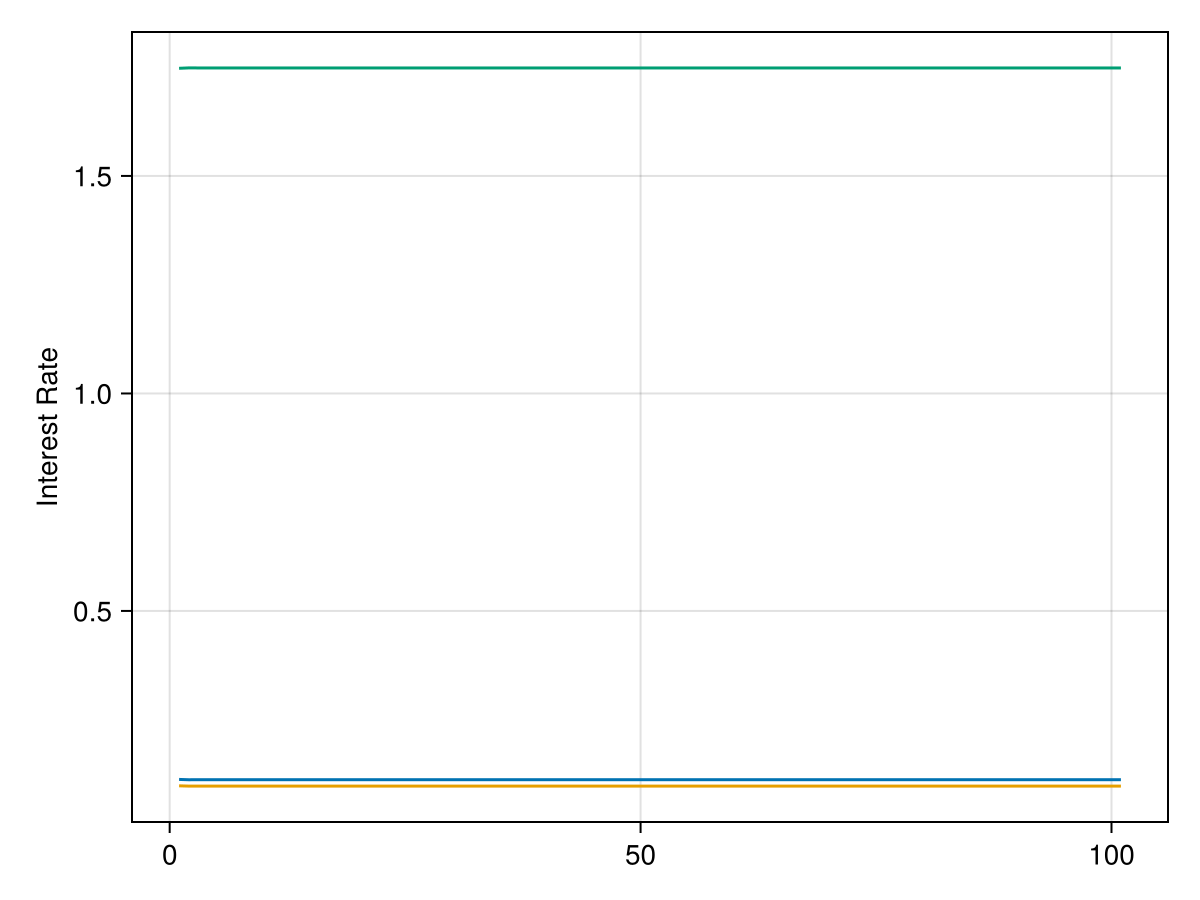

In [16]:
f = Figure()
ax = Axis(f[1,1], ylabel = "Interest Rate")

lines!(ax,sol_baseline.paths[:r], label = "Interest rate")
lines!(ax,sol_baseline.paths[:i], label = "Policy rate")
lines!(ax,sol_baseline.paths[:P], label = "Prices")
f

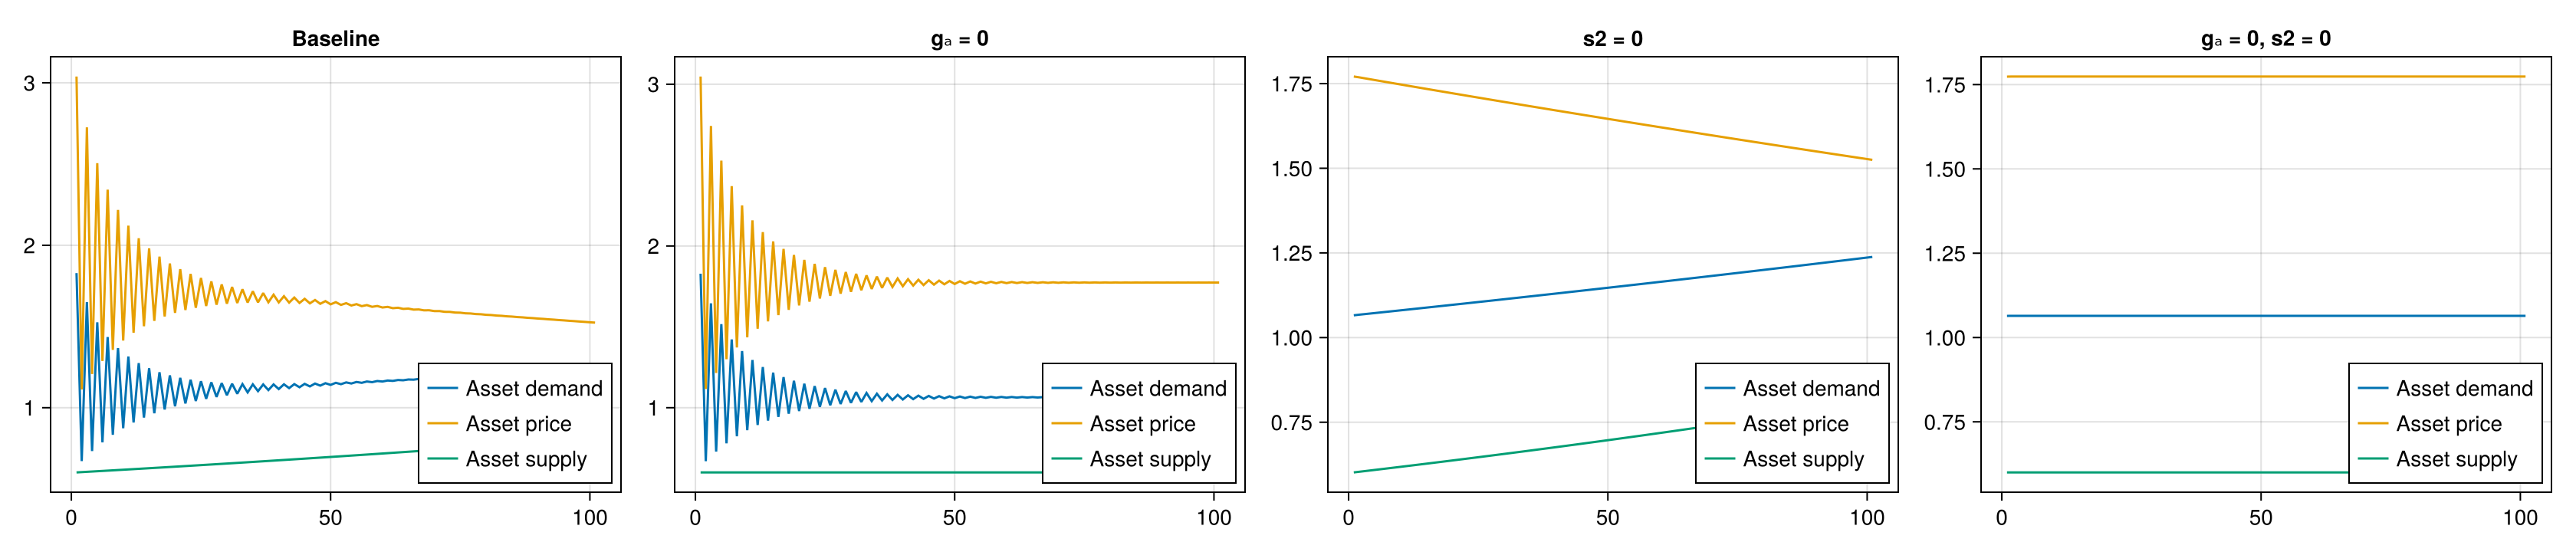

In [ ]:
steady_state_probe_cases = [
    (; label = "Baseline", sol =  Plotting.run_dynq_case()),
    (; label = "gₐ = 0", sol = Plotting.run_dynq_case(overwrites =  (:gₐ => 0.0,))),
    (; label = "s2 = 0", sol = Plotting.run_dynq_case( overwrites = (:s2 => 0.0,))),
    (; label = "gₐ = 0, s2 = 0", sol = Plotting.run_dynq_case( overwrites = (:gₐ => 0.0, :s2 => 0.0))),
]

Plotting.compare_dynq_cases(steady_state_probe_cases)
